# Task 1 - Financial AI: LLM-Powered Equity Research Assistant

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/GimsaraK/CDAZZDEV-MLE-Gimsara_Elgiriyage/blob/main/task1_financial/task1_equity_research.ipynb)

CDAZZDEV Senior Machine Learning Engineer Technical Assessment - Gimsara Elgiriyage

**Part 1A** builds the data ingestion and feature engineering module. All logic lives in reusable, unit-tested modules under [`task1_financial/src/`](src/); this notebook orchestrates them and shows the evidence.

| Module | Responsibility |
|---|---|
| `config.py` | Every tunable constant (no magic numbers elsewhere) |
| `data.py` | yfinance OHLCV + company info, validation and cleaning, snapshot fallback |
| `indicators.py` | SMA, EMA, Wilder RMA, RSI, MACD, Bollinger Bands from first principles |
| `news.py` | yfinance news + Google News RSS, de-duplication, snapshot fallback |
| `summary.py` | Momentum composite signal and the validated summary dictionary |
| `pipeline.py` | End-to-end orchestration that never raises |

## 0. Setup

In Colab the public repository is cloned and its requirements installed. Locally, the repository root is added to `sys.path`. Part 1A needs **no API keys** (yfinance and Google News RSS are keyless); Part 1B will read keys from Colab Secrets / `.env`, never from code.

In [1]:
# AI-ASSISTED: Cursor Agent (claude-sonnet-5.5), Prompt: 'yes implement the plan @TASK1A_PLAN.md', Date: 2026-10-08 (see CITATIONS.md Entry 4)

import subprocess
import sys
from pathlib import Path

REPO_URL = "https://github.com/GimsaraK/CDAZZDEV-MLE-Gimsara_Elgiriyage.git"
REPO_NAME = "CDAZZDEV-MLE-Gimsara_Elgiriyage"
IN_COLAB = "google.colab" in sys.modules

if IN_COLAB:
    repo_root = Path("/content") / REPO_NAME
    if not repo_root.exists():
        subprocess.run(["git", "clone", "--depth", "1", REPO_URL, str(repo_root)], check=True)
    subprocess.run(
        [sys.executable, "-m", "pip", "install", "-q", "-r", str(repo_root / "task1_financial" / "requirements.txt")],
        check=True,
    )
else:
    # Local run: this notebook lives in task1_financial/, so the repository root is its parent.
    cwd = Path.cwd().resolve()
    repo_root = cwd.parent if cwd.name == "task1_financial" else cwd

if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))
print(f"Running in Colab: {IN_COLAB}")
print(f"Repository root : .../{repo_root.name}")

Running in Colab: False
Repository root : .../CDAZZDEV-SMLE


In [2]:
# AI-ASSISTED: Cursor Agent (claude-sonnet-5.5), Prompt: 'yes implement the plan @TASK1A_PLAN.md', Date: 2026-10-08 (see CITATIONS.md Entry 4)

import json
from unittest import mock

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display

from task1_financial.src import config
from task1_financial.src import data as data_module
from task1_financial.src import indicators as ind
from task1_financial.src import news as news_module
from task1_financial.src.data import MarketData, load_market_data, validate_and_clean_ohlcv
from task1_financial.src.logging_utils import configure_logging
from task1_financial.src.news import get_headlines, news_to_records
from task1_financial.src.pipeline import run_pipeline
from task1_financial.src.summary import build_summary

%matplotlib inline
logger = configure_logging()
pd.set_option("display.width", 180)
pd.set_option("display.max_columns", 30)
pd.set_option("display.max_colwidth", 110)

## 1. Configuration

All parameters come from `src/config.py`. The history window is a **relative period string** (`"3y"`), never a hardcoded date: 3 years satisfies the 2-year minimum and leaves a full 2 years of valid 200-day SMA values after warm-up.

In [3]:
# AI-ASSISTED: Cursor Agent (claude-sonnet-5.5), Prompt: 'yes implement the plan @TASK1A_PLAN.md', Date: 2026-10-08 (see CITATIONS.md Entry 4)

settings = {
    "Ticker": config.TICKER,
    "History period (relative)": config.HISTORY_PERIOD,
    "Interval": config.HISTORY_INTERVAL,
    "Minimum history (years)": config.MIN_HISTORY_YEARS,
    "SMA windows": f"{config.SMA_SHORT_WINDOW}, {config.SMA_LONG_WINDOW}",
    "RSI period / smoothing": f"{config.RSI_PERIOD} / Wilder RMA (alpha = 1/{config.RSI_PERIOD})",
    "MACD (fast, slow, signal)": f"({config.MACD_FAST}, {config.MACD_SLOW}, {config.MACD_SIGNAL})",
    "Bollinger (window, std, ddof)": f"({config.BB_WINDOW}, {config.BB_NUM_STD}, {config.BB_STD_DDOF} = population)",
    "News target / minimum": f"{config.NEWS_TARGET_COUNT} / {config.NEWS_MIN_COUNT}",
    "Retry attempts": config.RETRY_MAX_ATTEMPTS,
}
display(pd.DataFrame(settings.items(), columns=["Setting", "Value"]).set_index("Setting"))

,Value
Setting,
Ticker,AAPL
History period (relative),3y
Interval,1d
Minimum history (years),2
SMA windows,"50, 200"
RSI period / smoothing,14 / Wilder RMA (alpha = 1/14)
"MACD (fast, slow, signal)","(12, 26, 9)"
"Bollinger (window, std, ddof)","(20, 2, 0 = population)"
News target / minimum,15 / 10


# Part 1A - Financial Data Pipeline

## 2. OHLCV Data Fetch

`load_market_data` fetches daily OHLCV with `auto_adjust=False`, so both the raw `Close` (matches quoted prices) and the split/dividend-adjusted `Adj Close` (used for indicators and returns) are available. Network calls are retried with exponential backoff; if the live fetch fails, the last committed snapshot in `task1_financial/data/` is used and the fallback is logged.

In [4]:
# AI-ASSISTED: Cursor Agent (claude-sonnet-5.5), Prompt: 'yes implement the plan @TASK1A_PLAN.md', Date: 2026-10-08 (see CITATIONS.md Entry 4)

market = load_market_data(config.TICKER)
ohlcv = market.ohlcv
quality = market.quality

assert quality.meets_min_history, f"Only {quality.span_years} years of history"
print(f"Ticker      : {market.ticker} ({market.info.get('longName', 'n/a')})")
print(f"Source      : {quality.source} (fetched at {quality.fetched_at})")
print(f"Rows        : {quality.rows} daily bars")
print(f"Date range  : {quality.start_date} -> {quality.end_date}  ({quality.span_years} years >= {config.MIN_HISTORY_YEARS} required)")
print(f"Data quality: {quality.warnings or 'no issues found'}")
display(ohlcv[list(config.REQUIRED_OHLCV_COLUMNS)].head(3))
display(ohlcv[list(config.REQUIRED_OHLCV_COLUMNS)].tail(3))

07:55:26 | INFO    | task1.data | Fetching 3y OHLCV history for AAPL (interval=1d)


07:55:27 | INFO    | task1.data | Saved market data snapshot for AAPL to task1_financial/data


07:55:27 | INFO    | task1.data | Loaded 752 live rows for AAPL (2023-10-09 to 2026-10-07)


Ticker      : AAPL (Apple Inc.)
Source      : live (fetched at 2026-10-08T02:25:27+00:00)
Rows        : 752 daily bars
Date range  : 2023-10-09 -> 2026-10-07  (3.0 years >= 2 required)
Data quality: no issues found


,Open,High,Low,Close,Adj Close,Volume
Date,,,,,,
2023-10-09,176.809998,179.050003,175.800003,178.990005,176.601456,42390800
2023-10-10,178.100006,179.720001,177.949997,178.389999,176.009445,43698000
2023-10-11,178.199997,179.850006,177.600006,179.800003,177.400650,47551100


,Open,High,Low,Close,Adj Close,Volume
Date,,,,,,
2026-10-05,332.820007,336.209991,331.649994,332.890015,332.890015,34400900
2026-10-06,332.279999,334.380005,330.619995,333.630005,333.630005,30449000
2026-10-07,336.959991,338.670013,332.779999,336.670013,336.670013,34128200


## 3. Technical Indicators (from first principles, no TA-Lib)

Computed on **Adj Close** by `src/indicators.py`:

| Indicator | Definition |
|---|---|
| SMA(n) | $SMA_t = \frac{1}{n}\sum_{i=0}^{n-1} P_{t-i}$, for n = 50 and 200 |
| EMA(n) | $EMA_t = \alpha P_t + (1-\alpha) EMA_{t-1}$, $\alpha = 2/(n+1)$, seeded with the first price (explicit recursion) |
| RSI(14) | $gain_t=\max(\Delta P_t,0)$, $loss_t=\max(-\Delta P_t,0)$; Wilder RMA: seed = mean of the first 14, then $RMA_t = (RMA_{t-1}\cdot 13 + x_t)/14$; $RSI = 100 - \frac{100}{1 + RMA(gain)/RMA(loss)}$ |
| MACD(12, 26, 9) | $MACD = EMA_{12} - EMA_{26}$; $Signal = EMA_9(MACD)$; $Histogram = MACD - Signal$ |
| Bollinger(20, 2) | $Middle = SMA_{20}$; $Upper/Lower = Middle \pm 2\sigma_{20}$ (population std); $\%B = \frac{P - Lower}{Upper - Lower}$ |

Every indicator is NaN until its warm-up window is complete, so no misleading early values are produced.

In [5]:
# AI-ASSISTED: Cursor Agent (claude-sonnet-5.5), Prompt: 'yes implement the plan @TASK1A_PLAN.md', Date: 2026-10-08 (see CITATIONS.md Entry 4)

prices = ind.add_indicators(ohlcv)

latest = prices.iloc[-1]
latest_table = pd.DataFrame(
    {
        "Value": [latest[config.PRICE_COL_ADJ], *[latest[c] for c in ind.INDICATOR_COLUMNS]],
    },
    index=[config.PRICE_COL_ADJ, *ind.INDICATOR_COLUMNS],
).round(4)
print(f"Latest indicator values as of {prices.index[-1].date()}:")
display(latest_table)
print("First valid date per indicator (warm-up):")
display(pd.Series({c: prices[c].first_valid_index().date() for c in ind.INDICATOR_COLUMNS}, name="first_valid"))

Latest indicator values as of 2026-10-07:


,Value
Adj Close,336.6700
SMA_50,322.2362
SMA_200,289.7328
RSI_14,57.6961
MACD,3.2824
MACD_Signal,4.1033
MACD_Hist,-0.8209
BB_Middle,334.4780
BB_Upper,341.7152
BB_Lower,327.2408


First valid date per indicator (warm-up):


SMA_50          2023-12-18
SMA_200         2024-07-25
RSI_14          2023-10-27
MACD            2023-11-13
MACD_Signal     2023-11-24
MACD_Hist       2023-11-24
BB_Middle       2023-11-03
BB_Upper        2023-11-03
BB_Lower        2023-11-03
BB_PctB         2023-11-03
BB_Bandwidth    2023-11-03
Name: first_valid, dtype: object

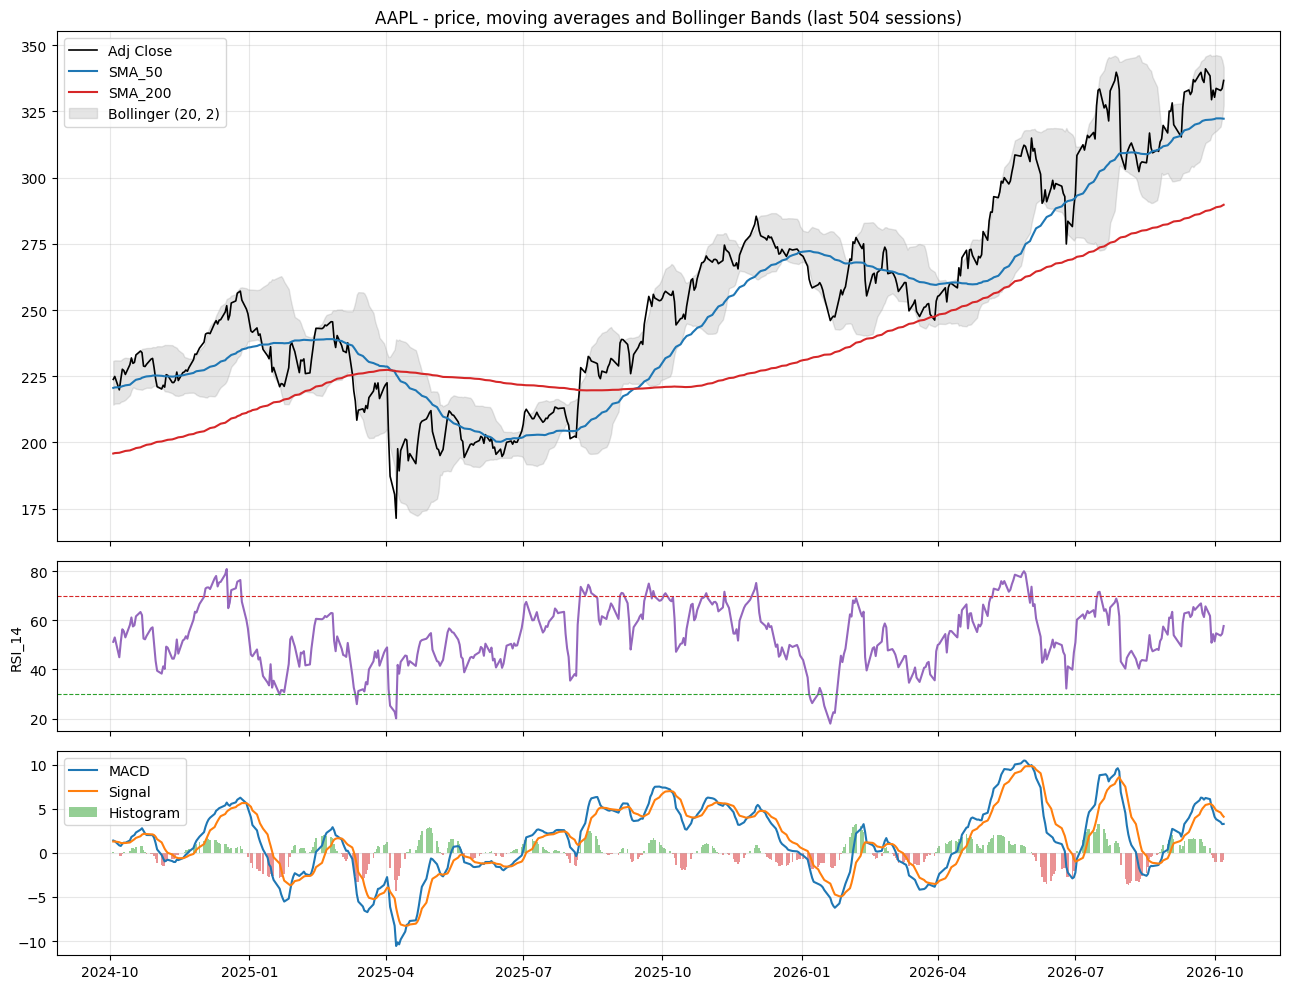

Chart saved to task1_financial\outputs\AAPL_technical_chart.png


In [6]:
# AI-ASSISTED: Cursor Agent (claude-sonnet-5.5), Prompt: 'yes implement the plan @TASK1A_PLAN.md', Date: 2026-10-08 (see CITATIONS.md Entry 4)

recent = prices.tail(config.CHART_LOOKBACK_SESSIONS)
fig, (ax_price, ax_rsi, ax_macd) = plt.subplots(
    3, 1, figsize=(13, 10), sharex=True, gridspec_kw={"height_ratios": [3, 1, 1.2]}
)

ax_price.plot(recent.index, recent[config.PRICE_COL_ADJ], label="Adj Close", color="black", linewidth=1.2)
ax_price.plot(recent.index, recent[ind.COL_SMA_SHORT], label=ind.COL_SMA_SHORT, color="tab:blue")
ax_price.plot(recent.index, recent[ind.COL_SMA_LONG], label=ind.COL_SMA_LONG, color="tab:red")
ax_price.fill_between(recent.index, recent[ind.COL_BB_LOWER], recent[ind.COL_BB_UPPER], color="tab:gray", alpha=0.2,
                      label=f"Bollinger ({config.BB_WINDOW}, {config.BB_NUM_STD})")
ax_price.set_title(f"{market.ticker} - price, moving averages and Bollinger Bands (last {len(recent)} sessions)")
ax_price.legend(loc="upper left")
ax_price.grid(alpha=0.3)

ax_rsi.plot(recent.index, recent[ind.COL_RSI], color="tab:purple")
ax_rsi.axhline(config.RSI_OVERBOUGHT, color="tab:red", linestyle="--", linewidth=0.8)
ax_rsi.axhline(config.RSI_OVERSOLD, color="tab:green", linestyle="--", linewidth=0.8)
ax_rsi.set_ylabel(ind.COL_RSI)
ax_rsi.grid(alpha=0.3)

ax_macd.plot(recent.index, recent[ind.COL_MACD], label="MACD", color="tab:blue")
ax_macd.plot(recent.index, recent[ind.COL_MACD_SIGNAL], label="Signal", color="tab:orange")
ax_macd.bar(recent.index, recent[ind.COL_MACD_HIST], label="Histogram",
            color=np.where(recent[ind.COL_MACD_HIST] >= 0, "tab:green", "tab:red"), width=1.0, alpha=0.5)
ax_macd.legend(loc="upper left")
ax_macd.grid(alpha=0.3)

fig.tight_layout()
config.OUTPUTS_DIR.mkdir(parents=True, exist_ok=True)
chart_path = config.OUTPUTS_DIR / config.CHART_OUTPUT_TEMPLATE.format(ticker=market.ticker)
fig.savefig(chart_path, dpi=config.CHART_DPI)
plt.show()
print(f"Chart saved to {chart_path.relative_to(repo_root)}")

### 3.1 Verification against an independent implementation

The open-source [`ta`](https://github.com/bukosabino/ta) library is used **only here, for validation** - never inside the pipeline. The comparison covers the last two years (after every warm-up window). Small RSI differences would come only from seeding (`ta` seeds Wilder's average with the first change; we follow Wilder's original simple-average seed) and decay geometrically, so they vanish long before the comparison window.

In [7]:
# AI-ASSISTED: Cursor Agent (claude-sonnet-5.5), Prompt: 'yes implement the plan @TASK1A_PLAN.md', Date: 2026-10-08 (see CITATIONS.md Entry 4)

from ta.momentum import RSIIndicator
from ta.trend import MACD as TaMACD
from ta.trend import SMAIndicator
from ta.volatility import BollingerBands

close = prices[config.PRICE_COL_ADJ]
ta_macd = TaMACD(close, window_slow=config.MACD_SLOW, window_fast=config.MACD_FAST, window_sign=config.MACD_SIGNAL)
ta_bb = BollingerBands(close, window=config.BB_WINDOW, window_dev=config.BB_NUM_STD)
reference = pd.DataFrame(
    {
        ind.COL_SMA_SHORT: SMAIndicator(close, config.SMA_SHORT_WINDOW).sma_indicator(),
        ind.COL_SMA_LONG: SMAIndicator(close, config.SMA_LONG_WINDOW).sma_indicator(),
        ind.COL_RSI: RSIIndicator(close, config.RSI_PERIOD).rsi(),
        ind.COL_MACD: ta_macd.macd(),
        ind.COL_MACD_SIGNAL: ta_macd.macd_signal(),
        ind.COL_MACD_HIST: ta_macd.macd_diff(),
        ind.COL_BB_MIDDLE: ta_bb.bollinger_mavg(),
        ind.COL_BB_UPPER: ta_bb.bollinger_hband(),
        ind.COL_BB_LOWER: ta_bb.bollinger_lband(),
    }
)

window = prices.index[-config.CHART_LOOKBACK_SESSIONS:]
diff = (prices.loc[window, reference.columns] - reference.loc[window]).abs()
crosscheck = pd.DataFrame(
    {
        "max_abs_diff": diff.max(),
        "max_rel_diff": (diff / reference.loc[window].abs()).max(),
    }
)
crosscheck["match (abs diff < 1e-6)"] = crosscheck["max_abs_diff"] < 1e-6
display(crosscheck)
assert crosscheck["match (abs diff < 1e-6)"].all(), "Indicator mismatch vs reference implementation"
print("All indicators match the independent reference implementation.")

,max_abs_diff,max_rel_diff,match (abs diff < 1e-6)
SMA_50,0.000000e+00,0.000000e+00,True
SMA_200,0.000000e+00,0.000000e+00,True
RSI_14,1.370781e-07,2.593955e-09,True
MACD,0.000000e+00,0.000000e+00,True
MACD_Signal,0.000000e+00,0.000000e+00,True
MACD_Hist,0.000000e+00,0.000000e+00,True
BB_Middle,0.000000e+00,0.000000e+00,True
BB_Upper,0.000000e+00,0.000000e+00,True
BB_Lower,0.000000e+00,0.000000e+00,True


All indicators match the independent reference implementation.


### 3.2 Unit tests

The test suite (`task1_financial/tests/`) runs offline. It checks the indicators against hand-computed values and the StockCharts RSI worked example, edge cases (flat, monotonic and NaN inputs), data cleaning, both news schemas, snapshot fallback, the P/E chain, YTD and 52-week logic, momentum thresholds, and that no hardcoded date strings exist in `src/`.

In [8]:
# AI-ASSISTED: Cursor Agent (claude-sonnet-5.5), Prompt: 'yes implement the plan @TASK1A_PLAN.md', Date: 2026-10-08 (see CITATIONS.md Entry 4)

tests_dir = repo_root / "task1_financial" / "tests"
completed = subprocess.run(
    [sys.executable, "-m", "pytest", str(tests_dir), "-q", "-p", "no:cacheprovider"],
    capture_output=True, text=True, cwd=repo_root,
)
print(completed.stdout[-3000:])
assert completed.returncode == 0, completed.stderr

........................................................................ [ 78%]
....................                                                     [100%]
92 passed in 1.09s



## 4. News Retrieval

`get_headlines` queries yfinance news first and tops up from the Google News RSS search (restricted to the last 7 days) until the target of 15 is reached. Results are curated before use:

1. **Low-signal items removed** (config regex): quote / options-chain listing pages and boilerplate institutional-holdings filing stories ("... Shares Sold by XYZ LLC"), which carry no sentiment signal.
2. **De-duplicated** on a normalised title, then **sorted newest first**.
3. **Capped at 3 headlines per publisher**, so no single outlet dominates the sample.

The publisher suffix Google appends to titles is moved into its own field. One failing source never stops the other; if live sources cannot reach the minimum of 10, the last snapshot is used.

In [9]:
# AI-ASSISTED: Cursor Agent (claude-sonnet-5.5), Prompt: 'yes implement the plan @TASK1A_PLAN.md', Date: 2026-10-08 (see CITATIONS.md Entry 4)

news = get_headlines(market.ticker, company_name=market.info.get("longName"))

assert news.count >= config.NEWS_MIN_COUNT, f"Only {news.count} headlines"
print(f"{news.count} headlines (minimum {config.NEWS_MIN_COUNT}) from: {news.sources_used}")
if news.warnings:
    print("Warnings:", news.warnings)
news_table = pd.DataFrame(news_to_records(news.items))
news_table.index = news_table.index + 1
display(news_table)

07:55:32 | INFO    | task1.news | News source yfinance returned 0 items (0 listing/filing items removed)


07:55:32 | INFO    | task1.news | News source google_rss returned 100 items (35 listing/filing items removed)


07:55:32 | INFO    | task1.news | Per-publisher cap (3) removed 29 items


15 headlines (minimum 10) from: ['google_rss']


,published_at,publisher,source,title
1,2026-10-07 21:37 UTC,The Motley Fool,google_rss,Nvidia Earned About Twice as Much as Apple Last Quarter. Its Stock Is Worth Only About 20% More.
2,2026-10-07 16:12 UTC,Yahoo Finance,google_rss,What Does Apple (AAPL) 24 7 Tokenized Trading Mean For Investors?
3,2026-10-07 08:33 UTC,Simply Wall Street,google_rss,Apple (AAPL) Shares Enter 24 7 Token Trading Plan In 63 Stock Filing
4,2026-10-07 05:19 UTC,Yahoo Finance,google_rss,NVIDIA (NVDA) vs. Apple (AAPL): Which Stock Wins the Valuation Race?
5,2026-10-07 02:32 UTC,24/7 Wall St.,google_rss,AAPL Stock Price Prediction 2026-2027 | Apple Forecast
6,2026-10-06 16:48 UTC,Yahoo Finance,google_rss,"Apple (AAPL): Buy, Sell, or Hold Post Q2 Earnings?"
7,2026-10-06 14:25 UTC,Trefis,google_rss,What Would It Take For Apple Stock To Move Higher?
8,2026-10-06 12:35 UTC,24/7 Wall St.,google_rss,Apple (AAPL) Trading Above Analyst Targets as Memory Costs Crimp Margin Outlook
9,2026-10-06 12:00 UTC,The Motley Fool,google_rss,22%: The One Number That Matters Most for Apple (AAPL) Shareholders
10,2026-10-05 23:23 UTC,MarketBeat,google_rss,"Apple (NASDAQ:AAPL) Stock: Insider Timothy Cook Sells 191,753 Shares"


## 5. Summary Dictionary

`build_summary` returns a validated Pydantic `StockSummary`; `.model_dump()` gives the clean dictionary.

| Field | Rule |
|---|---|
| `current_price` | Last **raw** close (matches quoted prices) |
| `week_52_high` / `week_52_low` | Raw High/Low within a **calendar** 52-week window; cross-checked against Yahoo's values |
| `pe_ratio` | `trailingPE`, else price / trailing EPS, else `None` with a stated reason (e.g. negative EPS) |
| `ytd_return` | **Adjusted** close vs the last close of the previous calendar year |
| `momentum` | Composite of 7 indicator rules, each voting +1 / -1 / 0; score = mean of the available votes, in [-1, 1] |

Momentum label: score >= 0.6 Strong Bullish, >= 0.2 Bullish, <= -0.2 Bearish, <= -0.6 Strong Bearish, otherwise Neutral. RSI beyond 70/30 and price outside the Bollinger Bands are treated as *stretched*: no vote, but flagged.

In [10]:
# AI-ASSISTED: Cursor Agent (claude-sonnet-5.5), Prompt: 'yes implement the plan @TASK1A_PLAN.md', Date: 2026-10-08 (see CITATIONS.md Entry 4)

summary = build_summary(market, prices, news)

print("Core summary (fields required by the specification):")
print(json.dumps(summary.core_dict(), indent=2))

summary_path = config.OUTPUTS_DIR / config.SUMMARY_OUTPUT_TEMPLATE.format(ticker=market.ticker)
summary_path.write_text(json.dumps(summary.model_dump(mode="json"), indent=2))
print(f"\nFull summary saved to {summary_path.relative_to(repo_root)}")

Core summary (fields required by the specification):
{
  "ticker": "AAPL",
  "current_price": 336.67,
  "week_52_high": 345.34,
  "week_52_low": 243.42,
  "pe_ratio": 38.61,
  "ytd_return": 0.2418,
  "momentum_signal": "Bullish",
  "momentum_score": 0.4286
}

Full summary saved to task1_financial\outputs\AAPL_summary.json


In [11]:
# AI-ASSISTED: Cursor Agent (claude-sonnet-5.5), Prompt: 'yes implement the plan @TASK1A_PLAN.md', Date: 2026-10-08 (see CITATIONS.md Entry 4)

print(f"Momentum: {summary.momentum.label} (score {summary.momentum.score})")
print(f"Flags   : {summary.momentum.flags or 'none'}")
display(pd.DataFrame([c.model_dump() for c in summary.momentum.components]).set_index("name"))

context = {
    "company_name": summary.company_name,
    "as_of_date": summary.as_of_date,
    "52w high date": summary.week_52_high_date,
    "52w low date": summary.week_52_low_date,
    "pe_source": summary.pe_source,
    "forward_pe": summary.forward_pe,
    "ytd_return_pct": summary.ytd_return_pct,
    "ytd_base": f"{summary.ytd_base_price} on {summary.ytd_base_date}",
    "news_count": summary.news_count,
    "warnings": summary.warnings or "none",
}
display(pd.Series(context, name="value").to_frame())

Momentum: Bullish (score 0.4286)
Flags   : none


,value,vote,rationale
name,,,
price_vs_sma_50,0.0448,1,Price relative to the 50-day SMA (short-term trend)
price_vs_sma_200,0.1620,1,Price relative to the 200-day SMA (long-term trend)
trend_regime,0.1122,1,SMA-50 above SMA-200 = golden-cross regime
macd_vs_signal,-0.8209,-1,MACD line above its signal line = positive momentum
macd_histogram_direction,-0.2133,-1,MACD histogram change over 5 sessions (accelerating vs fading)
rsi_zone,57.6961,1,"RSI 50-70 bullish, 30-50 bearish; beyond the bands = stretched (no vote, flagged)"
bollinger_pct_b,0.6514,1,"%B in the upper half of the bands bullish, lower half bearish; outside = stretched"


,value
company_name,Apple Inc.
as_of_date,2026-10-07
52w high date,2026-09-22
52w low date,2026-01-20
pe_source,trailingPE
forward_pe,35.13
ytd_return_pct,24.18
ytd_base,271.12 on 2025-12-31
news_count,15
warnings,none


In [12]:
# AI-ASSISTED: Cursor Agent (claude-sonnet-5.5), Prompt: 'yes implement the plan @TASK1A_PLAN.md', Date: 2026-10-08 (see CITATIONS.md Entry 4)

print("Full summary dictionary:")
print(json.dumps(summary.model_dump(mode="json"), indent=2))

Full summary dictionary:
{
  "ticker": "AAPL",
  "current_price": 336.67,
  "week_52_high": 345.34,
  "week_52_low": 243.42,
  "pe_ratio": 38.61,
  "ytd_return": 0.2418,
  "momentum": {
    "score": 0.4286,
    "label": "Bullish",
    "components": [
      {
        "name": "price_vs_sma_50",
        "value": 0.0448,
        "vote": 1,
        "rationale": "Price relative to the 50-day SMA (short-term trend)"
      },
      {
        "name": "price_vs_sma_200",
        "value": 0.162,
        "vote": 1,
        "rationale": "Price relative to the 200-day SMA (long-term trend)"
      },
      {
        "name": "trend_regime",
        "value": 0.1122,
        "vote": 1,
        "rationale": "SMA-50 above SMA-200 = golden-cross regime"
      },
      {
        "name": "macd_vs_signal",
        "value": -0.8209,
        "vote": -1,
        "rationale": "MACD line above its signal line = positive momentum"
      },
      {
        "name": "macd_histogram_direction",
        "value": -0.2133

## 6. Robustness Demonstrations

Each scenario below injects a failure and shows that it is handled, with a logged warning and a degraded-but-valid result instead of an unhandled exception.

In [13]:
# AI-ASSISTED: Cursor Agent (claude-sonnet-5.5), Prompt: 'yes implement the plan @TASK1A_PLAN.md', Date: 2026-10-08 (see CITATIONS.md Entry 4)

# 6.1 Unknown ticker: the pipeline returns status='failed' with a clear message instead of raising.
bad = run_pipeline("INVALIDXYZ123", save_snapshot=False)
print("status:", bad.status)
print("errors:", bad.errors)

07:55:32 | INFO    | task1.pipeline | === Task 1A pipeline start: INVALIDXYZ123 ===


07:55:32 | INFO    | task1.data | Fetching 3y OHLCV history for INVALIDXYZ123 (interval=1d)


07:55:33 | WARNING | task1.data | Live fetch failed for INVALIDXYZ123 (No price history returned for 'INVALIDXYZ123' (unknown or delisted symbol?)) - trying snapshot


07:55:33 | ERROR   | task1.pipeline | Pipeline failed for 'INVALIDXYZ123': Live fetch failed (No price history returned for 'INVALIDXYZ123' (unknown or delisted symbol?)) and no usable snapshot exists (No snapshot found for INVALIDXYZ123 in task1_financial/data)


status: failed
errors: ["Live fetch failed (No price history returned for 'INVALIDXYZ123' (unknown or delisted symbol?)) and no usable snapshot exists (No snapshot found for INVALIDXYZ123 in task1_financial/data)"]


In [14]:
# AI-ASSISTED: Cursor Agent (claude-sonnet-5.5), Prompt: 'yes implement the plan @TASK1A_PLAN.md', Date: 2026-10-08 (see CITATIONS.md Entry 4)

# 6.2 Corrupted data: NaN prices, a negative price, duplicate and unsorted rows.
corrupted = ohlcv.copy()
rng = np.random.default_rng(0)
nan_rows = rng.choice(len(corrupted), size=15, replace=False)
corrupted.iloc[nan_rows, corrupted.columns.get_loc(config.PRICE_COL_ADJ)] = np.nan
corrupted.iloc[5, corrupted.columns.get_loc(config.PRICE_COL_RAW)] = -1.0
corrupted = pd.concat([corrupted, corrupted.tail(3)]).sample(frac=1, random_state=0)

cleaned, report = validate_and_clean_ohlcv(corrupted)
degraded_summary = build_summary(MarketData(market.ticker, cleaned, market.info, report), ind.add_indicators(cleaned))
print("Cleaning report:", report.model_dump(include={"duplicate_rows_removed", "non_positive_prices_removed",
                                                    "rows_dropped_missing_price", "rows"}))
print("Summary still produced:", json.dumps(degraded_summary.core_dict()))

07:55:33 | WARNING | task1.data | Data quality: 3 duplicate dates removed


07:55:33 | WARNING | task1.data | Data quality: 1 non-positive prices treated as missing


07:55:33 | WARNING | task1.data | Data quality: 16 rows dropped (missing close)


Cleaning report: {'rows': 736, 'duplicate_rows_removed': 3, 'non_positive_prices_removed': 1, 'rows_dropped_missing_price': 16}
Summary still produced: {"ticker": "AAPL", "current_price": 336.67, "week_52_high": 345.34, "week_52_low": 243.42, "pe_ratio": 38.61, "ytd_return": 0.2418, "momentum_signal": "Bullish", "momentum_score": 0.4286}


In [15]:
# AI-ASSISTED: Cursor Agent (claude-sonnet-5.5), Prompt: 'yes implement the plan @TASK1A_PLAN.md', Date: 2026-10-08 (see CITATIONS.md Entry 4)

# 6.3 Missing company info (e.g. Yahoo's quote endpoint down): P/E becomes None with a reason.
no_info_summary = build_summary(MarketData(market.ticker, ohlcv, {}, quality), prices)
print("pe_ratio:", no_info_summary.pe_ratio, "| reason:", no_info_summary.pe_unavailable_reason)

# 6.4 Short history: SMA-200 based components are reported as unavailable, not crashed on.
short = ohlcv.tail(120)
short_quality = validate_and_clean_ohlcv(short)[1]
short_summary = build_summary(MarketData(market.ticker, short, market.info, short_quality), ind.add_indicators(short))
print("unavailable momentum components:", short_summary.momentum.unavailable)
print("score from remaining components:", short_summary.momentum.score, short_summary.momentum.label)

pe_ratio: None | reason: P/E and trailing EPS unavailable from the data source
07:55:33 | WARNING | task1.data | Data quality: History spans 0.47 years, below the 2-year minimum


07:55:33 | WARNING | task1.summary | Summary: Computed 52-week low 265.07 differs from Yahoo's 243.42 by 8.9%


07:55:33 | WARNING | task1.summary | Momentum components unavailable (insufficient data): ['price_vs_sma_200', 'trend_regime']


unavailable momentum components: ['price_vs_sma_200', 'trend_regime']
score from remaining components: 0.2 Bullish


In [16]:
# AI-ASSISTED: Cursor Agent (claude-sonnet-5.5), Prompt: 'yes implement the plan @TASK1A_PLAN.md', Date: 2026-10-08 (see CITATIONS.md Entry 4)

# 6.5 Live market data outage: the committed snapshot is used and the fallback is logged.
with mock.patch.object(data_module, "fetch_ohlcv", side_effect=ConnectionError("simulated network outage")):
    offline_market = load_market_data(config.TICKER, save_snapshot=False)
print("source:", offline_market.quality.source, "| rows:", offline_market.quality.rows)
print("warning:", offline_market.quality.warnings[0])

# 6.6 Both news sources down: the news snapshot is used.
outage = mock.Mock(side_effect=ConnectionError("simulated outage"))
with mock.patch.object(news_module, "fetch_yfinance_news", outage), \
     mock.patch.object(news_module, "fetch_google_news_rss", outage):
    offline_news = get_headlines(config.TICKER, save_snapshot=False)
print("headlines:", offline_news.count, "| from snapshot:", offline_news.from_snapshot)

07:55:33 | WARNING | task1.data | Live fetch failed for AAPL (simulated network outage) - trying snapshot


source: snapshot | rows: 752
07:55:33 | WARNING | task1.news | News source yfinance failed: simulated outage


07:55:33 | WARNING | task1.news | News source google_rss failed: simulated outage


07:55:33 | WARNING | task1.news | Using news snapshot fetched at 2026-10-08T02:25:32+00:00 (15 items)


headlines: 15 | from snapshot: True


### Part 1A result

The pipeline fetched 3 years of daily data for the configured ticker, computed all five indicators (verified against unit tests and an independent library), retrieved 10+ recent headlines from free sources, and produced a validated summary dictionary. Every failure mode above was handled without an unhandled exception.

# Part 1B - LLM Sentiment and Signal Reasoning

_To be implemented next._

# Bonus - Equity Research Brief

_To be implemented after Part 1B._

## Citations

See [`CITATIONS.md`](../CITATIONS.md) in the repository root. AI-assisted cells and modules carry an inline `# AI-ASSISTED:` comment.